# CNN model to detect COVID-19

## Pre-requisites

### Importing libraries

In [1]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.preprocessing.image import ImageDataGenerator

### Setting the paths of the dataset and images to be classified

In [2]:
dataset_path = 'covid19\\train'
test_dir = 'covid19\\test'

### Setting the parameters 

In [3]:
img_size = 128
num_classes = len(os.listdir(dataset_path))
batch_size = 32

### Creating the image and the labels

In [4]:
from sklearn.preprocessing import LabelBinarizer

def load_dataset():
    images = []
    lbls = []
    labels = []
    classes = os.listdir(dataset_path)
    label_binarizer = LabelBinarizer()
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):  # Check if the current item is a directory
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)
                try:
                    image = cv2.imread(image_path)
                    if image is not None:  # Check if the image was loaded successfully
                        image = cv2.resize(image, (img_size, img_size))
                        images.append(image)
                        lbls.append(class_name)
                    else:
                        print(f"Skipping invalid image: {image_path}")
                except Exception as e:
                    print(f"Error loading image: {image_path}")
                    print(str(e))
    # Convert labels to unique binary arrays
    labels = label_binarizer.fit_transform(lbls)
    return images, lbls, labels

Images that are not in the correct format are skipped.

In [5]:
images, lbls, labels = load_dataset()

In [6]:
# Create a set to keep track of unique labels
printed_labels = set()
# Create a counter to keep track fo the label count
no_of_labels = 0
# Print lbls and corresponding labels
for labelName, arr in zip(lbls, labels):
    # Check if the label has already been printed
    if labelName not in printed_labels:
        # Print the disease and array
        print("Label:", labelName, ", Array:", arr)
        # Add the disease to the set of printed diseases
        printed_labels.add(labelName)
        # Increment the disease counter
        no_of_labels = no_of_labels + 1

print()
print("No. of labels:", no_of_labels)

Label: Covid , Array: [1 0 0]
Label: Normal , Array: [0 1 0]
Label: Viral Pneumonia , Array: [0 0 1]

No. of labels: 3


### Preprocessing the dataset

In [7]:
def preprocess_dataset(images, labels):
    images = np.array(images)
    images = images.astype('float32') / 255.0
    labels = np.array(labels)
    return images, labels

In [8]:
images, labels = preprocess_dataset(images, labels)

The labels after preprocessing are stored as a NumPy array

In [9]:
print(labels)

[[1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 

## Creating the Convolutional Neural Network (CNN)

### Splitting the data into a training and testing set 

In [10]:
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

### Creating the CNN model

In [11]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

### Compiling the CNN model

In [12]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### Augmenting the training data 

In [13]:
data_generator = ImageDataGenerator(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
data_generator.fit(train_images)

### Training the model with the training data

The history variable stores the values of accuracy and loss after each epoch, which are then used to plot the graph

In [14]:
history = model.fit(data_generator.flow(train_images, train_labels, batch_size=batch_size), steps_per_epoch=len(train_images) // batch_size, epochs=35)

Epoch 1/35
6/6 [==============================] - 3s 326ms/step - loss: 1.4405 - accuracy: 0.4531
Epoch 2/35
6/6 [==============================] - 2s 261ms/step - loss: 1.0920 - accuracy: 0.4107
Epoch 3/35
6/6 [==============================] - 2s 264ms/step - loss: 1.0729 - accuracy: 0.4345
Epoch 4/35
6/6 [==============================] - 2s 233ms/step - loss: 1.0360 - accuracy: 0.4524
Epoch 5/35
6/6 [==============================] - 2s 249ms/step - loss: 0.9435 - accuracy: 0.5260
Epoch 6/35
6/6 [==============================] - 2s 237ms/step - loss: 0.8808 - accuracy: 0.6667
Epoch 7/35
6/6 [==============================] - 2s 287ms/step - loss: 0.6561 - accuracy: 0.7857
Epoch 8/35
6/6 [==============================] - 2s 280ms/step - loss: 0.5012 - accuracy: 0.8036
Epoch 9/35
6/6 [==============================] - 1s 272ms/step - loss: 0.4400 - accuracy: 0.8274
Epoch 10/35
6/6 [==============================] - 2s 235ms/step - loss: 0.4973 - accuracy: 0.8036
Epoch 11/35
6/6 [==

### The graphs of accuracy and loss after each epoch are plotted

Accuracy shows a logarithmic trend, while loss shows an exponential trend

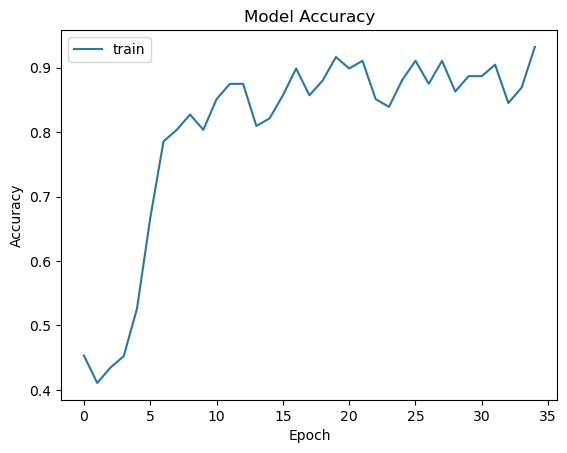

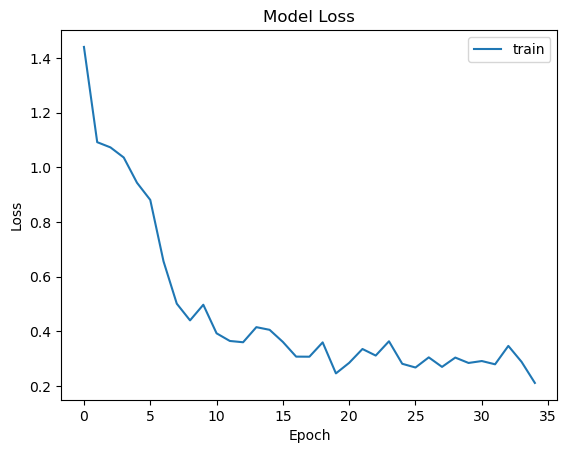

In [15]:
# Plot accuracy
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Plot loss
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

### Evaluating the model

The model's loss and accuracy is evaluted against the test data

In [16]:
# Evaluate the model
loss, accuracy = model.evaluate(test_images, test_labels)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

2/2 [==============================] - 0s 55ms/step - loss: 0.4685 - accuracy: 0.9020
Test Loss: 0.46849149465560913
Test Accuracy: 0.9019607901573181


A testing accuracy of 88% indicates that the model is accurate

## Classifying images 

### Initializing the arrays

In [17]:
images_to_be_classified = os.listdir(test_dir)
resized_images = []

### Preprocessing the images

This is done to make the images compatible with the model, as it can function accurately only if a particular format of images is used

In [18]:
for image_name in images_to_be_classified:
    # Construct the full path to the image
    image_path = os.path.join(test_dir, image_name)
    # Load the image using OpenCV
    image = cv2.imread(image_path)
    # Resize the image
    resized_image = cv2.resize(image, (img_size, img_size))
    # Append the resized image to the list
    resized_images.append(resized_image)

In [19]:
resized_images = np.array(resized_images)

In [20]:
resized_images = resized_images / 255.0

### Predicting image labels

In [21]:
predictions = model.predict(resized_images)

2/2 [==============================] - 0s 105ms/step


### Printing image names along with their corresponding labels

In [22]:
printed_labels = list(printed_labels)
printed_labels.sort()
print(printed_labels)

['Covid', 'Normal', 'Viral Pneumonia']


In [23]:
for i in range(len(images_to_be_classified)):
    image_name = images_to_be_classified[i]
    prediction = predictions[i]
    pred_label = ""
    rounded_prediction = np.round(prediction)
    for i in range(len(rounded_prediction)):
        if rounded_prediction[i] == 1:
            labelName = printed_labels[i]
    print("Image:", image_name, "Prediction:", labelName)

Image: covid (1).jpeg Prediction: Covid
Image: covid (1).jpg Prediction: Covid
Image: covid (1).png Prediction: Covid
Image: covid (10).jpeg Prediction: Covid
Image: covid (11).jpeg Prediction: Covid
Image: covid (12).jpeg Prediction: Covid
Image: covid (2).jpeg Prediction: Covid
Image: covid (2).jpg Prediction: Covid
Image: covid (2).png Prediction: Normal
Image: covid (3).jpeg Prediction: Covid
Image: covid (3).jpg Prediction: Covid
Image: covid (3).png Prediction: Covid
Image: covid (4).jpeg Prediction: Covid
Image: covid (4).jpg Prediction: Covid
Image: covid (5).jpeg Prediction: Covid
Image: covid (5).jpg Prediction: Covid
Image: covid (6).jpeg Prediction: Covid
Image: covid (6).jpg Prediction: Covid
Image: covid (7).jpeg Prediction: Normal
Image: covid (8).jpeg Prediction: Normal
Image: covid (9).jpeg Prediction: Covid
Image: normal (1).jpeg Prediction: Normal
Image: normal (10).jpeg Prediction: Normal
Image: normal (11).jpeg Prediction: Normal
Image: normal (12).jpeg Prediction:

### Saving the model

The model is saved as an H5 file. This format is used as both weights and model configuration can be stored in the same file.

In [24]:
model.save('covid19model.h5')